# Build a Trail Observation Buffer

Create and validate a **0.5-mile buffer** around **Mackinac | North Country Trail**.

The buffer follows the entire trail geometry. In the next project step, it can be used to request recent iNaturalist observations near the trail.


## 1. Load the grouped trail data

Load the processed trail groups and define the trail, projected coordinate system, and buffer distance used in this notebook.

**Why EPSG:3078?** It uses meters, so the buffer distance can be calculated accurately for a Michigan trail.


In [20]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt


DATA_PATH = Path(
    "../data/processed/dnr_up_hiking_trails_grouped.parquet"
)

TRAIL_NAME = "Mackinac | North Country Trail"
PROJECTED_CRS = "EPSG:3078"

MILES_TO_METERS = 1609.344
BUFFER_MILES = 1
BUFFER_METERS = BUFFER_MILES * MILES_TO_METERS

print(f"Buffer distance: {BUFFER_METERS:.2f} meters")


Buffer distance: 1609.34 meters


## 2. Validate the source data

Confirm that the file exists and contains the name and geometry fields required for this task.


In [21]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Trail data was not found: {DATA_PATH.resolve()}"
    )

trails = gpd.read_parquet(DATA_PATH)

required_columns = ["TrailGroupName", "geometry"]

missing_columns = [
    column
    for column in required_columns
    if column not in trails.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

if trails.empty:
    raise ValueError("The grouped trail dataset is empty.")

if trails.crs is None:
    raise ValueError("The grouped trail dataset has no CRS.")

if trails.geometry.isna().any():
    raise ValueError("The grouped trail dataset contains missing geometry.")

print(f"Grouped trails: {len(trails):,}")
print(f"Source CRS: {trails.crs}")


Grouped trails: 159
Source CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "

## 3. Select the Mackinac County trail

Filter the grouped dataset to one record for the selected trail. A clear error is raised if the name is missing or duplicated.


In [22]:
selected_trail = trails[
    trails["TrailGroupName"] == TRAIL_NAME
].copy()

if selected_trail.empty:
    similar_names = (
        trails.loc[
            trails["TrailGroupName"]
            .str.contains("North Country", case=False, na=False),
            "TrailGroupName",
        ]
        .sort_values()
        .tolist()
    )

    raise ValueError(
        f"Trail not found: {TRAIL_NAME}\n"
        f"Similar trail names: {similar_names}"
    )

if len(selected_trail) != 1:
    raise ValueError(
        f"Expected one trail record but found {len(selected_trail)}."
    )

if selected_trail.geometry.is_empty.any():
    raise ValueError("The selected trail has empty geometry.")

if not selected_trail.geometry.is_valid.all():
    raise ValueError("The selected trail has invalid geometry.")

selected_trail[
    [
        column
        for column in [
            "TrailGroupName",
            "TrailLengthMiles",
            "LengthCategory",
            "SegmentCount",
        ]
        if column in selected_trail.columns
    ]
]


,TrailGroupName,TrailLengthMiles,LengthCategory,SegmentCount
84,Mackinac | North Country Trail,40.707007,Long,24


## 4. Project the trail and create the buffer

Convert the trail to EPSG:3078 before buffering. Buffering longitude and latitude directly would produce incorrect distance units.


In [23]:
trail_projected = selected_trail.to_crs(PROJECTED_CRS)

# Explicitly create a GeoDataFrame with the buffered geometry.
trail_buffer = gpd.GeoDataFrame(
    trail_projected[["TrailGroupName"]].copy(),
    geometry=trail_projected.geometry.buffer(BUFFER_METERS),
    crs=trail_projected.crs,
)

if trail_buffer.geometry.is_empty.any():
    raise ValueError("The trail buffer is empty.")

if not trail_buffer.geometry.is_valid.all():
    raise ValueError("The trail buffer geometry is invalid.")

print(f"Projected CRS: {trail_projected.crs}")
print(f"Buffer distance: {BUFFER_MILES} mile")

Projected CRS: EPSG:3078
Buffer distance: 1 mile


## 5. Plot the trail and buffer

The trail line should remain visible inside a continuous buffer that follows the entire trail.


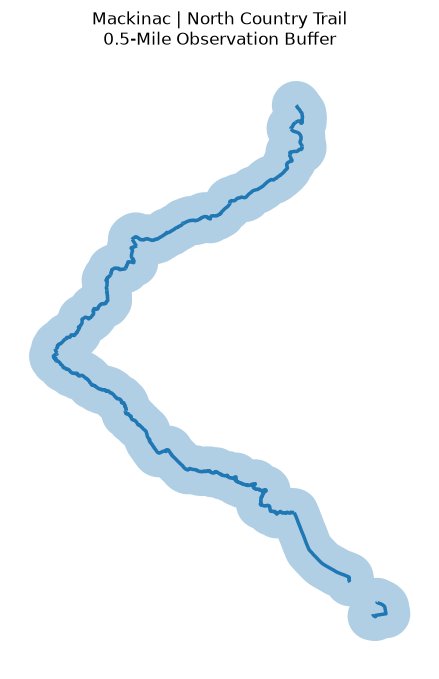

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

trail_buffer.plot(
    ax=ax,
    alpha=0.35,
    zorder=1,
)

trail_projected.plot(
    ax=ax,
    linewidth=2.5,
    zorder=2,
)

ax.set_title(
    "Mackinac | North Country Trail\n"
    "1-Mile Observation Buffer"
)
ax.set_axis_off()

plt.show()


## 6. Prepare the API bounding box

iNaturalist can first search the rectangular bounds around the buffer. Returned observation points will later be filtered against the exact buffer polygon.


In [25]:
buffer_wgs84 = trail_buffer.to_crs("EPSG:4326")

west, south, east, north = buffer_wgs84.total_bounds

api_bounds = {
    "swlat": south,
    "swlng": west,
    "nelat": north,
    "nelng": east,
}

api_bounds


{'swlat': np.float64(45.83847628226667),
 'swlng': np.float64(-85.00788469597789),
 'nelat': np.float64(46.17243535533801),
 'nelng': np.float64(-84.68594517076718)}

## Validation check

This step is complete when:

- exactly one trail record is selected;
- the trail and buffer use EPSG:3078 during the distance calculation;
- the buffer is valid and fully covers the trail;
- the plot shows a continuous buffer around the full trail geometry;
- the API bounding coordinates appear reasonable for Michigan.

## Next step

Request the past 14 days of iNaturalist observations inside the bounding box, then keep only observation points located inside the exact 0.5-mile buffer.


In [29]:
from datetime import date, timedelta

import pandas as pd
import requests


API_URL = "https://api.inaturalist.org/v1/observations"

end_date = date.today()
start_date = end_date - timedelta(days=13)

params = {
    **api_bounds,
    "d1": start_date.isoformat(),
    "d2": end_date.isoformat(),
    "verifiable": "true",
    "mappable": "true",
    "iconic_taxa[]": [
        "Aves",
        "Mammalia",
        "Plantae",
        "Fungi",
        "Reptilia",
        "Insecta",
    ],
    "per_page": 200,
    "page": 1,
    "order_by": "observed_on",
    "order": "desc",
}

headers = {
    "User-Agent": "Whats-UP-Outdoors/0.1"
}

response = requests.get(
    API_URL,
    params=params,
    headers=headers,
    timeout=30,
)
response.raise_for_status()

data = response.json()
results = data["results"]

rows = []

for observation in results:
    taxon = observation.get("taxon") or {}
    geojson = observation.get("geojson") or {}
    coordinates = geojson.get("coordinates", [None, None])

    rows.append(
        {
            "observation_id": observation.get("id"),
            "observed_on": observation.get("observed_on"),
            "quality_grade": observation.get("quality_grade"),
            "common_name": taxon.get("preferred_common_name"),
            "scientific_name": taxon.get("name"),
            "taxon_rank": taxon.get("rank"),
            "iconic_taxon": taxon.get("iconic_taxon_name"),
            "longitude": coordinates[0],
            "latitude": coordinates[1],
            "positional_accuracy": observation.get("positional_accuracy"),
            "coordinates_obscured": observation.get(
                "coordinates_obscured"
            ),
            "observation_url": observation.get("uri"),
        }
    )

observations = pd.DataFrame(rows)

print(f"Date range: {start_date} to {end_date}")
print(f"Matching observations: {data['total_results']:,}")
print(f"Downloaded this page: {len(observations):,}")

observations

Date range: 2026-07-22 to 2026-08-04
Matching observations: 68
Downloaded this page: 68


,observation_id,observed_on,quality_grade,common_name,scientific_name,taxon_rank,iconic_taxon,longitude,latitude,positional_accuracy,coordinates_obscured,observation_url
0,388158495,2026-08-04,needs_id,green bog orchid,Platanthera huronensis,species,Plantae,-84.721979,45.986340,4.0,None,https://www.inaturalist.org/observations/38815...
1,388152661,2026-08-04,needs_id,smooth saw-grass,Cladium mariscoides,species,Plantae,-84.724983,45.987100,4.0,None,https://www.inaturalist.org/observations/38815...
2,388152450,2026-08-04,needs_id,white flat-topped goldenrod,Solidago ptarmicoides,species,Plantae,-84.724991,45.987106,4.0,None,https://www.inaturalist.org/observations/38815...
3,388151801,2026-08-04,needs_id,Mountain Deathcamas,Anticlea elegans,species,Plantae,-84.725037,45.987197,4.0,None,https://www.inaturalist.org/observations/38815...
4,387905844,2026-08-03,research,red baneberry,Actaea rubra,species,Plantae,-84.724146,45.847068,544.0,None,https://www.inaturalist.org/observations/38790...
...,...,...,...,...,...,...,...,...,...,...,...,...
63,384753542,2026-07-23,research,Hine's Emerald,Somatochlora hineana,species,Insecta,-84.840767,45.882155,4.0,None,https://www.inaturalist.org/observations/38475...
64,385392317,2026-07-22,research,chicory,Cichorium intybus,species,Plantae,-84.718808,45.865213,4.0,None,https://www.inaturalist.org/observations/38539...
65,385392249,2026-07-22,needs_id,Japanese Spirea,Spiraea japonica,species,Plantae,-84.717461,45.865396,4.0,None,https://www.inaturalist.org/observations/38539...
66,385392176,2026-07-22,research,wild carrot,Daucus carota,species,Plantae,-84.716983,45.865516,3.0,None,https://www.inaturalist.org/observations/38539...


In [31]:
from IPython.display import HTML, display

rows = []

for observation in results:
    taxon = observation.get("taxon") or {}
    geojson = observation.get("geojson") or {}
    photos = observation.get("photos") or []

    coordinates = geojson.get("coordinates", [None, None])
    thumbnail_url = photos[0].get("url") if photos else None

    rows.append(
        {
            "observation_id": observation.get("id"),
            "observed_on": observation.get("observed_on"),
            "taxon_id": taxon.get("id"),
            "common_name": taxon.get("preferred_common_name"),
            "scientific_name": taxon.get("name"),
            "taxon_rank": taxon.get("rank"),
            "iconic_taxon": taxon.get("iconic_taxon_name"),
            "longitude": coordinates[0],
            "latitude": coordinates[1],
            "thumbnail_url": thumbnail_url,
        }
    )

observations = pd.DataFrame(rows)

# Keep only observations identified to species.
species_observations = observations.loc[
    observations["taxon_rank"] == "species"
].copy()

species_observations["observed_on"] = pd.to_datetime(
    species_observations["observed_on"],
    errors="coerce",
)

# Sort newest first so each species uses its most recent available photo.
species_observations = species_observations.sort_values(
    "observed_on",
    ascending=False,
)

species_summary = (
    species_observations.groupby(
        [
            "iconic_taxon",
            "taxon_id",
            "common_name",
            "scientific_name",
        ],
        dropna=False,
    )
    .agg(
        observation_count=("observation_id", "nunique"),
        thumbnail_url=("thumbnail_url", "first"),
    )
    .reset_index()
)

species_summary["common_name"] = species_summary[
    "common_name"
].fillna(species_summary["scientific_name"])

taxon_groups = {
    "Birds": "Aves",
    "Mammals": "Mammalia",
    "Plants": "Plantae",
    "Fungi": "Fungi",
    "Reptiles": "Reptilia",
    "Insects": "Insecta",
}


def show_thumbnail(url):
    if pd.isna(url):
        return "No image"

    return (
        f'<img src="{url}" '
        f'width="75" height="75" '
        f'alt="Species thumbnail">'
    )


for group_label, iconic_taxon in taxon_groups.items():
    group_table = (
        species_summary.loc[
            species_summary["iconic_taxon"] == iconic_taxon,
            [
                "thumbnail_url",
                "common_name",
                "scientific_name",
                "observation_count",
            ],
        ]
        .sort_values(
            ["observation_count", "common_name"],
            ascending=[False, True],
        )
        .head(5)
        .rename(
            columns={
                "thumbnail_url": "Thumbnail",
                "common_name": "Common name",
                "scientific_name": "Scientific name",
                "observation_count": "Observations",
            }
        )
        .copy()
    )

    print(f"\n{group_label}")

    if group_table.empty:
        print("No species-level observations found.")
        continue

    group_table["Thumbnail"] = group_table[
        "Thumbnail"
    ].apply(show_thumbnail)

    display(
        HTML(
            group_table.to_html(
                index=False,
                escape=False,
            )
        )
    )


Birds


Thumbnail,Common name,Scientific name,Observations
,Ring-billed Gull,Larus delawarensis,2
,Canada Goose,Branta canadensis,1
,Double-crested Cormorant,Nannopterum auritum,1
,Greater Yellowlegs,Tringa melanoleuca,1



Mammals
No species-level observations found.

Plants


Thumbnail,Common name,Scientific name,Observations
,Mezereon,Daphne mezereum,2
,red osier dogwood,Cornus sericea,2
,wild carrot,Daucus carota,2
,wild parsnip,Pastinaca sativa,2
,American Cranberry,Vaccinium macrocarpon,1



Fungi
No species-level observations found.

Reptiles


Thumbnail,Common name,Scientific name,Observations
,Smooth Greensnake,Opheodrys vernalis,1



Insects


Thumbnail,Common name,Scientific name,Observations
,Asian Lady Beetle,Harmonia axyridis,1
,Confused Haploa Moth,Haploa confusa,1
,European Chafer,Amphimallon majale,1
,Hine's Emerald,Somatochlora hineana,1
,Incurvate Emerald,Somatochlora incurvata,1
